# MA-StatDig — Exercice 4.3 : Enregistrements Finis
### Version 1.0 — 2025 (MTN) | M. Tognolini, HEIG-VD

**Méthode d'Autocorrélation (ACM)**

Cet exercice complète le laboratoire 4.3 en se concentrant sur l'implémentation et l'analyse de la méthode d'autocorrélation appliquée à des enregistrements de données finis.

### Importation des librairies et Déclaration des fonctions

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
import pywt as wt


---


# 1. Théorie — Transformée de Haar Forward

La transformée de Haar est la transformée en ondelettes orthogonales la plus simple. Elle décompose un signal en **moyennes** et **différences** locales entre échantillons pairs et impairs, de façon itérative.

À chaque niveau de décomposition, pour un signal $x$ de longueur $N$ :

$$a_k = \frac{x_{2k} + x_{2k+1}}{\sqrt{2}} \qquad \text{(coefficients de lissage)}$$

$$d_k = \frac{x_{2k} - x_{2k+1}}{\sqrt{2}} \qquad \text{(coefficients de détail)}$$

Le signal est ainsi séparé en deux sous-bandes de longueur $N/2$ :
- $a_k$ — approximation basse fréquence (moyenne locale)
- $d_k$ — détails haute fréquence (différence locale)

On applique ensuite récursivement la même opération sur $a_k$ pour obtenir une décomposition multi-résolution.

> **Propriété clé — Orthogonalité :** Les ondelettes de Haar forment une base orthonormée de $L^2$ — la transformée conserve l'énergie du signal (théorème de Parseval) et est parfaitement inversible par la transformée inverse.

> **Lien avec les filtres :** La transformée de Haar est équivalente à un banc de filtres à deux canaux — un filtre passe-bas (moyenne) et un filtre passe-haut (différence), suivis d'un sous-échantillonnage par 2.


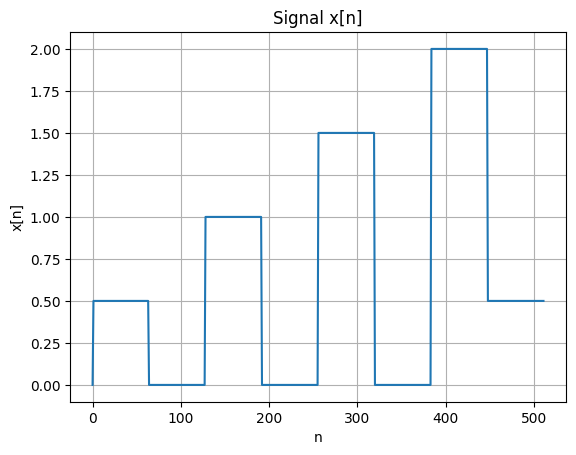

In [ ]:
# N is the size of the signal
N= 512

# Exemple of square pice regular signal x[n]
x = np.zeros(N)
x[0] = 0
x[1:64] = 0.5
x[128:192] = 1.0
x[256:320] = 1.5
x[384:448] = 2.0
x[448:512] = 0.5

# Plot the signal
plt.figure()
plt.plot(x)
plt.title('Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

## Décomposition multi-échelle

La transformée de Haar opère sur $J = \log_2(N) - 1$ échelles. À chaque échelle $j$, elle produit deux séries de coefficients de longueur $N_j = 2^j$ :

- $a_j \in \mathbb{R}^{N_j}$ — coefficients d'**approximation** (basse fréquence) à l'échelle $j$
- $d_j \in \mathbb{R}^{N_j}$ — coefficients de **détail** (haute fréquence) à l'échelle $j$

La décomposition complète sur $J$ niveaux donne donc :

$$x \longrightarrow \{a_J,\ d_J,\ d_{J-1},\ \dots,\ d_1\}$$

où $a_J$ est l'approximation la plus grossière (un seul coefficient si $J = \log_2(N) - 1$) et $d_1$ contient les détails à la résolution la plus fine.

> **Interprétation multi-résolution :** À l'échelle $j$ grossière, chaque coefficient $a_j(k)$ représente la moyenne du signal sur une fenêtre de $2^{J-j}$ échantillons — plus $j$ est petit, plus la fenêtre est large et la résolution temporelle faible, mais la résolution fréquentielle est élevée.

> **Conservation de l'information :** La transformée est parfaitement réversible — le nombre total de coefficients $\{a_J, d_J, \dots, d_1\}$ est égal à $N$, aucune information n'est perdue.

In [ ]:
J = np.log2(N)-1
print("J=",J)  

J= 8.0


## Algorithme rapide — Banc de filtres de Haar

L'algorithme de transformée en ondelettes rapide (FWT) n'utilise pas explicitement les ondelettes $\Psi$ et fonctions d'échelle $\Phi$, mais uniquement les **filtres** $h$ et $g$ qui caractérisent leur interaction :

$$g[n] = \frac{1}{\sqrt{2}} \langle \Psi(t/2),\, \Phi(t-n) \rangle \qquad \text{(filtre passe-haut — détails)}$$

$$h[n] = \frac{1}{\sqrt{2}} \langle \Phi(t/2),\, \Phi(t-n) \rangle \qquad \text{(filtre passe-bas — approximation)}$$

Pour l'ondelette de Haar, ces filtres sont les plus simples possible :

$$h = \frac{1}{\sqrt{2}}[1,\ 1] \qquad g = \frac{1}{\sqrt{2}}[-1,\ 1]$$

> **Interprétation :** $h$ calcule une **moyenne** locale (passe-bas), $g$ calcule une **différence** locale (passe-haut). À chaque niveau, on applique les deux filtres puis on sous-échantillonne par 2 — c'est le schéma classique du banc de filtres à deux canaux.

> **Conditions d'orthogonalité :** Les filtres de Haar vérifient $\|h\|^2 = \|g\|^2 = 1$ et $\langle h, g \rangle = 0$ — ils forment une paire orthonormée, ce qui garantit la conservation de l'énergie et la reconstruction parfaite.

In [6]:
#The fast wavelet transform algorithm does not make use of the wavelet and scaling functions, but of the filters h and g that caracterize their interaction:

h = np.array([(1/np.sqrt(2)), (1/np.sqrt(2))])
g = np.array([(-1/np.sqrt(2)), (1/np.sqrt(2))])

print("h=",h)
print("g=",g)

h= [0.70710678 0.70710678]
g= [-0.70710678  0.70710678]


## Filtres de descente et montée (Down/Up Sampling)

### Analyse (décomposition) — Filtres de descente

L'opération fondamentale de la transformée en ondelettes est un **filtrage suivi d'un sous-échantillonnage par 2**. À partir d'un signal $f \in \mathbb{R}^N$, on calcule :

$$a = (f * h)\downarrow 2 \qquad \text{(approximation — passe-bas)}$$
$$d = (f * g)\downarrow 2 \qquad \text{(détails — passe-haut)}$$

où le sous-échantillonnage est défini par :

$$(u \downarrow 2)[k] = u[2k]$$

On ne conserve qu'un échantillon sur deux après filtrage — d'où la réduction de taille $N \rightarrow N/2$ pour chaque sous-bande.

### Synthèse (reconstruction) — Filtres de montée

L'opération inverse sur-échantillonne par 2 avant de filtrer :

$$(u \uparrow 2)[k] = \begin{cases} u[k/2] & \text{si } k \text{ pair} \\ 0 & \text{si } k \text{ impair} \end{cases}$$

Le signal est reconstruit par :

$$f = (a \uparrow 2) * \tilde{h} + (d \uparrow 2) * \tilde{g}$$

> **Conservation de l'énergie :** Grâce à l'orthogonalité des filtres de Haar, la reconstruction est parfaite — aucune information n'est perdue lors de la décomposition analyse/synthèse.

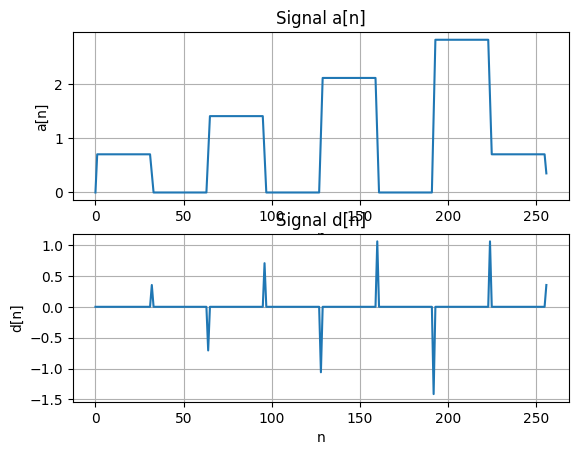

In [ ]:
f = x

# a = subsampling by 2 the  convolution  f * g
a = np.convolve(f, h, mode='full')[::2]   # passe-bas

# d = subsampling by 2 the  convolution  f * h
d = np.convolve(f, g, mode='full')[::2]   # passe-haut

# Plot the signal
plt.figure()
plt.subplot(2,1,1)
plt.plot(a)
plt.title('Signal a[n]')
plt.xlabel('n')
plt.ylabel('a[n]')
plt.grid()

plt.subplot(2,1,2)
plt.plot(d)
plt.title('Signal d[n]')
plt.xlabel('n')
plt.ylabel('d[n]')
plt.grid()
plt.show()


## Reconstruction — Sur-échantillonnage et filtres inverses

Pour des filtres orthogonaux, la reconstruction est le dual de la décomposition : **sur-échantillonnage suivi d'un filtrage** avec les filtres retournés $\tilde{h}$ et $\tilde{g}$ :

$$(a \uparrow 2) * \tilde{h} + (d \uparrow 2) * \tilde{g} = f$$

où :
- $\tilde{h}[n] = h[-n]$ — filtre passe-bas retourné (calculé modulo $N$)
- $\tilde{g}[n] = g[-n]$ — filtre passe-haut retourné
- $(u \uparrow 2)[2n] = u[n]$ et $(u \uparrow 2)[2n+1] = 0$ — insertion de zéros entre chaque échantillon

> **Pour les filtres de Haar :** Comme $h = [1,1]/\sqrt{2}$ est symétrique, $\tilde{h} = h$. De même $\tilde{g} = [-1, 1]/\sqrt{2}$ devient $[1, -1]/\sqrt{2}$.

In [ ]:
# Sur-échantillonnage (upsampling x2)
def upsample(u):
    u_up = np.zeros(2 * len(u))
    u_up[::2] = u       # échantillons pairs = u[n], impairs = 0
    return u_up

# Filtres de Haar retournés
h_tilde = h[::-1]      # = h pour Haar (symétrique)
g_tilde = g[::-1]      # = [1, -1] / sqrt(2)

# Reconstruction
f_reconstructed = (np.convolve(upsample(a), h_tilde, mode='full') +
                   np.convolve(upsample(d), g_tilde, mode='full'))

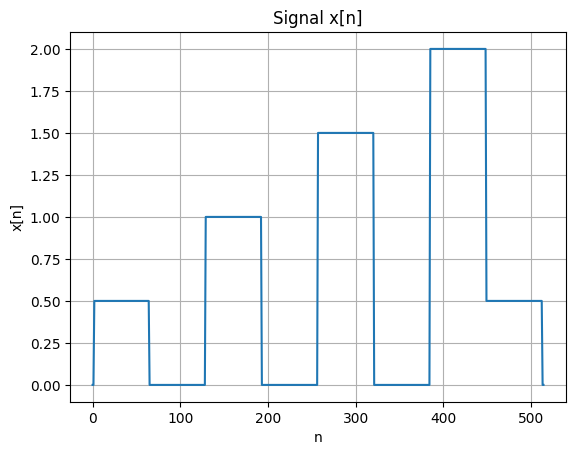

In [10]:
# Plot the signal
plt.figure()
plt.plot(f_reconstructed)
plt.title('Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()